# Basic Numerical Methods


## 1. Least Squares Method and Regression Analysis



### a. Least Squares Method

The least squares method minimizes the sum of squared differences between observed and predicted values. It's used to find the best-fitting line in regression analysis.

Mathematically:
$$
	{Error} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
Where:
$$
(y_i) = actual value
$$
$$
(\hat{y}_i) = predicted value$$
$$
    


### b. Simple Linear Regression Example

Goal of Linear Regression:

We want to find the best-fitting line: \( y = mx + b \)

Design Matrix A:
 [[1. 1.]
 [2. 1.]
 [3. 1.]
 [4. 1.]
 [5. 1.]]
Slope (m): 0.75
Intercept (b): 1.39
Residuals: [0.027]
Rank of matrix A: 2
Singular values of A: [7.69121313 0.91936964]


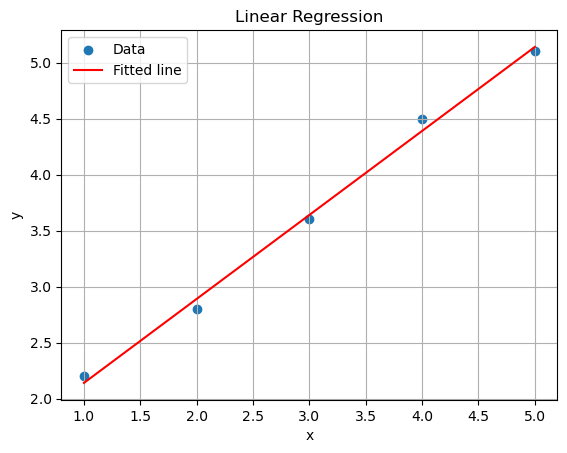

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Design matrix construction based on data points
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.2,2.8,3.6,4.5,5.1])

# Step 2: Build matrix A: Each row represents the linear model y=mx+c.
A = np.vstack([x, np.ones(len(x))]).T # Stack x and a column of ones and then transpose it
print ("Design Matrix A:\n", A) # The first column is the value of x. The second column is always 1, which allows us to solve for the intercept c.

# Step 3: Fit line using least squares- it solves for the slope m and intercept c of the best-fit line
# np.linalg.lstsq returns a tuple (coeffs, residuals, rank, s), so unpack accordingly.
coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
m = coeffs[0]
b = coeffs[1]

# Step 4: Output the results and plot them
print("Slope (m):", m)
print("Intercept (b):", b)
print("Residuals:", residuals)
print("Rank of matrix A:", rank)
print("Singular values of A:", s) 

plt.scatter(x, y, label='Data')
plt.plot(x, m*x + b, 'r', label='Fitted line')
plt.legend()
plt.title('Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


#### Exercise- Make up a set of data and find their best fit using least squares linear regression.

Matrix V:
 [[ 3.  1.]
 [ 7.  1.]
 [18.  1.]
 [ 2.  1.]
 [14.  1.]]
Slope (m): 0.41991786447638607
Intercept (b): 5.104722792607806
Residuals: [8.45071869]
Rank of matrix V: 2
Singular values of V: [24.19371816  1.28996183]


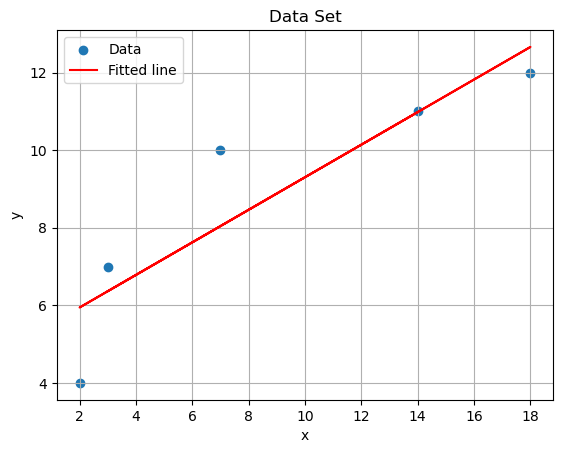

In [3]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt

x = np.array([3, 7, 18, 2, 14])
y = np.array([7, 10, 12, 4, 11])

V = np.vstack([x, np.ones(len(x))]).T
print ("Matrix V:\n", V)

coeffs, residuals, rank, s = np.linalg.lstsq(V, y, rcond=None)
m = coeffs[0]
b = coeffs[1]

print("Slope (m):", m)
print("Intercept (b):", b)
print("Residuals:", residuals)
print("Rank of matrix V:", rank)
print("Singular values of V:", s) 

plt.scatter(x, y, label='Data')
plt.plot(x, m*x + b, 'r', label='Fitted line')
plt.legend()
plt.title('Data Set')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


## 2. Root Finding Methods in Numerical Analysis

This notebook demonstrates two popular numerical methods for finding roots of equations:

1. **Bisection Method**
2. **Newton-Raphson Method**

We will use the function:
\[ f(x) = x^3 - 2x - 5 \]



### a. Bisection Method

The Bisection Method is a simple and robust technique for finding roots of a continuous function. It works by repeatedly halving an interval and selecting the subinterval in which the function changes sign.

#### Algorithm Steps:
1. Define the function f(x)
2. Choose interval [a, b] where f(a) * f(b) < 0
3. Repeat until convergence:
   - Compute midpoint c = (a + b)/2
   - Evaluate f(c)
   - If f(c) * f(a) < 0, set b = c
   - Else, set a = c
   - Stop when |f(c)| is small enough


f(a): -6.0
f(b): -1.0
Iteration: 1
f(c): -4.625
Iteration: 2
f(c): -3.140625
Iteration: 3
f(c): -2.158203125
Iteration: 4
f(c): -1.601806640625
Iteration: 5
f(c): -1.306671142578125
Iteration: 6
f(c): -1.1547889709472656
Iteration: 7
f(c): -1.0777592658996582
Iteration: 8
f(c): -1.0389710068702698
Iteration: 9
f(c): -1.0195083692669868
Iteration: 10
f(c): -1.0097599038854241
Root found using Bisection Method: 1.9990234375
Residuals: [8.45071869]
Rank of matrix A: 2
Singular values of A: [24.19371816  1.28996183]


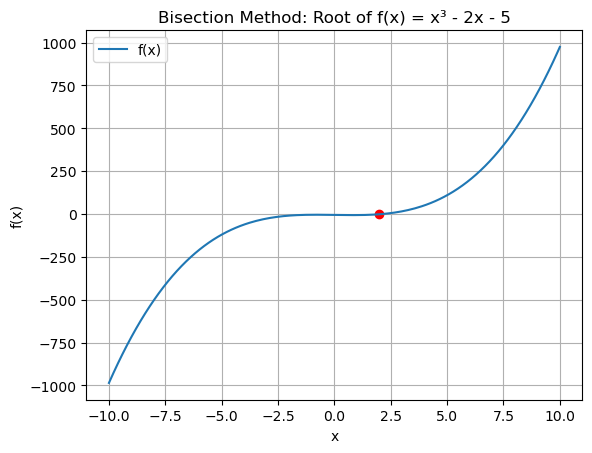

In [23]:
# Complete the Bisection Method implementation

def f(x):
    return x**3 - 2*x - 5
a = 1.
b = 2.
print("f(a):", f(a))
print("f(b):", f(b))
tolerance = 0.000001
iterations = 10

i = 0
root_bisection = None

while i < iterations:
    print("Iteration:", i+1)
    c = (a + b) / 2
    print("f(c):", f(c))
    if f(c) * f(a) < 0:
        b = c
    else:
        a = c
    i += 1
    if abs(f(c)) <= tolerance:
        root_bisection = c
        break

if root_bisection is None:
    root_bisection = c

print("Root found using Bisection Method:", root_bisection)

# Your code to plot the function and the root found
x = np.linspace(-10, 10, 200)
y = f(x)

print("Residuals:", residuals)
print("Rank of matrix A:", rank)
print("Singular values of A:", s) 

plt.figure()
plt.plot(x, y, label='f(x)')
plt.scatter([root_bisection], [f(root_bisection)], color='red')
plt.title("Bisection Method: Root of f(x) = x³ - 2x - 5")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


### b. Newton-Raphson Method

The Newton-Raphson Method is an efficient technique for finding roots using the function's derivative.

#### Algorithm Steps:
1. Define the function and its deriative

2. Start with an initial guess \( x_0 \).

3. Repeat 
   Compute the next approximation using:

   $$ x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} $$

   Until:

   $$ |x_{n+1} - x_n| < \varepsilon $$

4. Return the final approximation $$ x_{n+1} $$ as the root.



In [ ]:
# Complete the Newton-Raphson Method implementation
def f(x):
    return x**3 - 2*x - 5 # Defining the functions

def df(x):
    return 3*x**2 - 2

x0 = 1.5
tolerance = 0.000001
max_iterations = 10
i = 0
root_newton = None # when finding the root

while i < max_iterations: # interations cannot exceed max_iterations
    x_new0 = x0 - (f(x0) / df(x0))
    if abs(x_new0 - x0) < tolerance: # Check for convergence
        root_newton = x_new0
        break
    x0 = x_new0 # Update for next one
    i += 1 # Increment iteration count

if root_newton is None: #when not converged within max_iterations
    root_newton = x0

print("Root found using Newton-Raphson Method:", root_newton)
print("f(root):", f(root_newton)) # Displays the function value at the found root


Root found using Newton-Raphson Method: 2.0945514815423265
f(root): -8.881784197001252e-16


### Root finding exercise: Beam Deflection

A simply supported beam of length (L = 10m ) is subjected to a uniformly distributed load w = 5 kN/m. The deflection y(x) of the beam at a distance x from the left support is given by:

$$
y(x) = \frac{w}{24EI} \, x \left( L^3 - 2Lx^2 + x^3 \right)
$$

#### 🎯 Task:
Use a root-finding method (e.g., Newton-Raphson or Bisection) to find the position \( x \) along the beam where the **maximum deflection** occurs.

#### 💡 Hint:
To find the maximum deflection:
1. Compute the derivative y'(x) 
2. Solve y'(x) = 0  within the interval x in [0, L] 

#### 📌 Constants:
- L = 10 
- w = 5 
- E and I are constants (you may assume EI = 1 for simplicity)

In [ ]:
# Your code here
w = 5
EI = 1 # set variables w/ constants given
L = 10

def f(x):
    return (w/(24*EI)) * x * (L**3 - 2*L*(x**2) + x**3) #defining the original function

def df(x):
    return (w/(24*EI)) * (L**3 - 6*L*(x**2) + 4*(x**3)) #defining the derivative of the original function

a = 0
b = 10 #initial guess
tolerance = 0.000001 #tolerance level
max_iterations = 100
i = 0 #iteration counter

if df(a) * df(b) > 0:
    print("No root found in this range, try different a and b values.")
else:
    i = 0
    while i < max_iterations: #bisection method loop
        c = (a + b) / 2
        if abs(df(c)) < tolerance: #check for convergence
            break

        if df(a) * df(c) < 0: #decide which subinterval to choose
            b = c
        else:
            a = c
        i += 1

root_bisection = c #final root value
print("Position of maximum deflection (x):", root_bisection)

Position of maximum deflection (x): 5.0
